Binary cross-entropy loss:

$$
L(w,b) = -\frac{1}{n} \sum_{i=1}^n \Big[ y^{(i)} \log \hat{y}^{(i)} + (1 - y^{(i)}) \log (1 - \hat{y}^{(i)}) \Big]
$$


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
## Generate sample data
np.random.seed(0)
n = 200
temp_1 = np.random.randn(n//2, 2) + np.array([-2, -2])
temp_2 = np.random.randn(n//2, 2) + np.array([2, 2])

X = np.vstack([temp_1, temp_2])
y = np.array([0]*(n//2) + [1]*(n//2))

# parameters
lr = 0.1
epochs = 200

In [4]:
## Helper functions
# sigmoid activation function
# binary cross-entropy loss function
# logit calculation z = wx + b; (eg: 0 -> 50% confident since sigmoid(0) = 0.5)
# gradients; calculated by hand via blast from the past ap calc chain rule

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def loss(y, ypred):
    eps = 1e-12
    ypred = np.clip(ypred, eps, 1 - eps)
    return -np.mean(y * np.log(ypred) + (1 - y) * np.log(1 - ypred))

def forward(X, w, b):
    z = np.dot(X, w) + b     # the logit, represents model confidence in predicitng class 1 here
                                # higher logit means higher confidence
    yhat = sigmoid(z)        # prediction = logit passed through sigmoid
    return yhat              # vectorized computation

def backward(X, y, ypred):
    n = len(X)
    error = ypred - y

    dw = (1/n) * np.dot(X.T, error)    # these are the gradients, take derivative of loss function
    db = (1/n) * np.sum(error)         # gradient function already calculated, plug in values here
    return dw, db

In [5]:
# initialize parameters

losses = []
w = np.zeros(X.shape[1])
b = 0.0


## Train model
for epoch in range(epochs):    
  ypred = forward(X, w, b)

  current_loss = loss(y, ypred)  # calculate loss function

  dw, db = backward(X, y, ypred)  # calculate gradients

  w -= lr*dw                     # subtract to move in opposite direction of gradient
  b -= lr*db

  losses.append(current_loss)

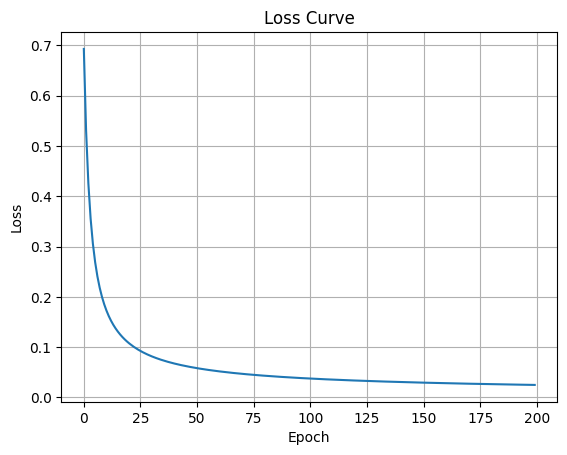

In [6]:
# Plot Loss Curve

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.grid(True)
plt.show()